# 04 — Simulating TOA reflectance

This notebook demonstrates `SmartgSampler_Rho_toa_sym`, which computes the top-of-atmosphere reflectance $\rho_{toa}$ from a known surface $\rho_s$.

## How it works

The adjacency effect is characterised by the PSF (Point Spread Function) of the atmosphere: photons scattered sideways by aerosols arrive at the sensor from neighbouring pixels. Under the assumption that the PSF is **radially symmetric**, `SmartgSampler_Rho_toa_sym` exploits this structure:

1. It estimates the approximate radial profile of $\rho_{toa}$ from the input $\rho_s$.
2. It selects a small set of **adaptive radial sampling points** (by gradient-driven CDF inversion) — typically 50–100 points instead of the full 2D grid.
3. It runs a **single Smart-G simulation** with one sensor per radial sample point, yielding the TOA signal at each radius.
4. It reconstructs the full 2D $\rho_{toa}$ field from the radial profile via Pchip interpolation.

This reduces the number of photon transport simulations by several orders of magnitude compared to a pixel-by-pixel approach.

The underlying hypthesis is that the viewing zenith angle of the satellite (VZA) is close to nadir. In practice, the simulation remains valid for low Viewing Zenith Angles (<20°). Performances start to decrease significally over 50°. In order to perform exact simulation of the $\rho_{toa}$, please use the `SmartgSampler_Rho_toa`.

**Requires:** GPU + `SMARTG_DIR_AUXDATA`.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

import adjeff
from adjeff.atmosphere import AtmoConfig, GeoConfig, SpectralConfig
from adjeff.core import S2Band, gaussian_image_dict
from adjeff.modules.samplers import SmartgSampler_Rho_toa_sym

assert "SMARTG_DIR_AUXDATA" in os.environ

## 4.1 — Setup: surface and atmospheric state

First, we setup a single atmosphere with 3 different Sentinel-2 bands, and disk surface reflectance maps with a fixed $10~m$ resolution, a radius of $3.0~km$ and a $(1001, 1001)$ input size.

In [2]:
BANDS = [S2Band.B02, S2Band.B03, S2Band.B04]

# Create a Gaussian surface (bright target, dark background)
scene = gaussian_image_dict(
    sigma=3.0,        # 300 m half-width
    res_km=0.01,      # 10 m resolution
    rho_min=0.05,
    rho_max=0.6,
    bands=BANDS,
    n=1001,
)

atmo = AtmoConfig(
    aot=xr.DataArray([0.6], dims=["aot"]),
    h=xr.DataArray([0.0], dims=["h"]),
    rh=xr.DataArray([50.0], dims=["rh"]),
    href=xr.DataArray([2.0], dims=["href"]),
    species={"sulphate": 1.0},
)

geo = GeoConfig(
    sza=xr.DataArray([30.0], dims=["sza"]),
    vza=xr.DataArray([0.0], dims=["vza"]),
    saa=xr.DataArray([120.0], dims=["saa"]),
    vaa=xr.DataArray([0.0], dims=["vaa"]),
)

spectral = SpectralConfig.from_bands(BANDS)

2026-04-15 11:50:38 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)]
2026-04-15 11:50:38 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=1001 rho_max=0.6 rho_min=0.05 sigma=3.0 var=rho_s
2026-04-15 11:50:38 [debug    ] Created Gaussian Image.        band=S2Band.B03(560.0nm) n=1001 rho_max=0.6 rho_min=0.05 sigma=3.0 var=rho_s
2026-04-15 11:50:38 [debug    ] Created Gaussian Image.        band=S2Band.B04(665.0nm) n=1001 rho_max=0.6 rho_min=0.05 sigma=3.0 var=rho_s


## 4.2 — Run the TOA simulation

The TOA reflectance siulation can now be performed for each bands.

In [3]:
module = SmartgSampler_Rho_toa_sym(
    atmo_config=atmo,
    geo_config=geo,
    remove_rayleigh=False,
    nr=80,           # number of radial sampling points
    n_ph=int(5e5),   # photons per sensor — increase for less noise
)

scene = module(scene)
print("Variables available after module:")
for var in scene[S2Band.B02].data_vars:
    print(f"  {var}: {list(scene[S2Band.B02][var].dims)}")

2026-04-15 11:50:38 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=2ff1f39b module=SmartgSampler_Rho_toa_sym
2026-04-15 11:50:38 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['species', 'sat_height'] scalars=['sza', 'vza'] vectors=['aot', 'rh', 'h', 'href']
2026-04-15 11:50:38 [debug    ] Initialization finshed.        arrays={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} deduplicated=False flat_dims=[]
2026-04-15 11:50:38 [info     ] Starting compute               bands=[S2Band.B02(490.0nm), S2Band.B03(560.0nm), S2Band.B04(665.0nm)] key=5906e9f1 module=SmartgSampler_Rho_atm
2026-04-15 11:50:38 [debug    ] Aggregated ConfigBundle parameters.. das={'wl': ['wl'], 'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['band_ty

Box(children=(FloatProgress(value=0.0, max=90000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:50:43 [info     ] rho_atm successfully calculated.
2026-04-15 11:50:43 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 3, 1, 1, 1, 1)
2026-04-15 11:50:43 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-15 11:50:43 [info     ] Computation finished           key=5906e9f1 module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-15 11:50:43 [info     ] Start rho_toa computation.     band=S2Band.B02(490.0nm)
2026-04-15 11:50:43 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-15 11:50:43 [debug    ] Atmosphere LUT generation. wl=490.0, aot=0.6, rh=50.0, href=2.0, h=0.0
2026-04-15 11:50:43 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=51500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:50:52 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 1001, 1001)
2026-04-15 11:50:52 [info     ] Computed rho_toa.              band=S2Band.B02(490.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-15 11:50:52 [info     ] Start rho_toa computation.     band=S2Band.B03(560.0nm)
2026-04-15 11:50:52 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-15 11:50:52 [debug    ] Atmosphere LUT generation. wl=560.0, aot=0.6, rh=50.0, href=2.0, h=0.0
2026-04-15 11:50:52 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=51500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:51:00 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 1001, 1001)
2026-04-15 11:51:00 [info     ] Computed rho_toa.              band=S2Band.B03(560.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-15 11:51:00 [info     ] Start rho_toa computation.     band=S2Band.B04(665.0nm)
2026-04-15 11:51:00 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-15 11:51:00 [debug    ] Atmosphere LUT generation. wl=665.0, aot=0.6, rh=50.0, href=2.0, h=0.0
2026-04-15 11:51:00 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=51500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:51:07 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 1001, 1001)
2026-04-15 11:51:07 [info     ] Computed rho_toa.              band=S2Band.B04(665.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-15 11:51:07 [info     ] Computation finished           key=2ff1f39b module=SmartgSampler_Rho_toa_sym vars=['rho_toa']
Variables available after module:
  rho_s: ['y', 'x']
  rho_atm: ['vza', 'sza', 'aot', 'rh', 'href', 'h']
  rho_toa: ['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x']


## 4.3 — Compare ρ_s and ρ_toa

Then, it is straighforward to compare the initial surface reflectance and the simulated TOA reflectance. 

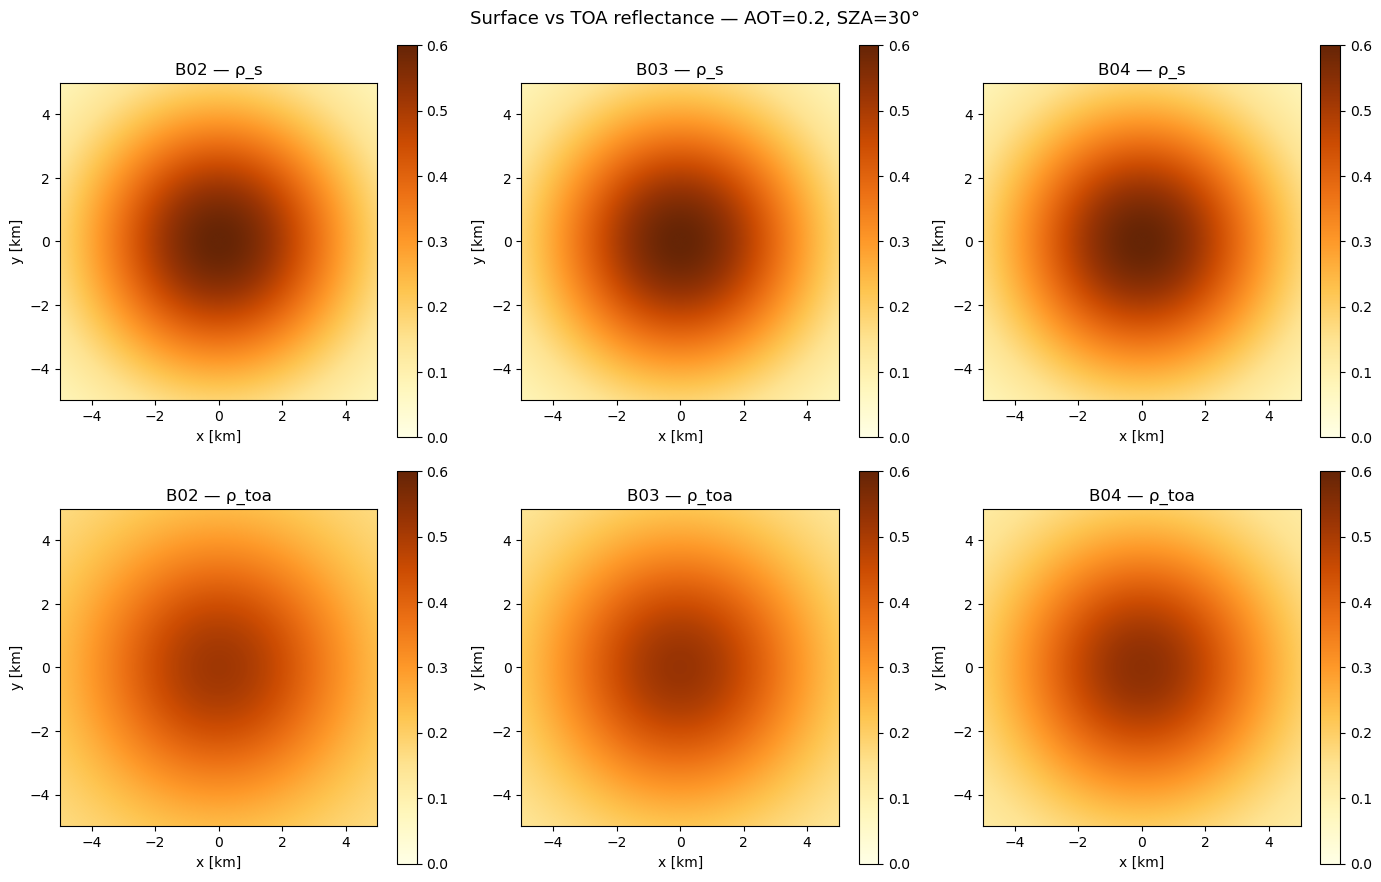

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(14, 9))

for col, band in enumerate(BANDS):
    ds = scene[band]
    rho_s = ds["rho_s"].values
    rho_toa = ds["rho_toa"].squeeze().values

    coords = ds["rho_s"]
    extent = [
        float(coords.coords["x"].min()), float(coords.coords["x"].max()),
        float(coords.coords["y"].min()), float(coords.coords["y"].max()),
    ]
    vmax = max(rho_s.max(), rho_toa.max())

    for row, (data, title) in enumerate([(rho_s, "ρ_s"), (rho_toa, "ρ_toa")]):
        ax = axes[row, col]
        im = ax.imshow(data, origin="lower", extent=extent, vmin=0, vmax=vmax, cmap="YlOrBr")
        ax.set_title(f"{band.id} — {title}")
        ax.set_xlabel("x [km]")
        ax.set_ylabel("y [km]")
        plt.colorbar(im, ax=ax)

fig.suptitle("Surface vs TOA reflectance — AOT=0.2, SZA=30°", fontsize=13)
plt.tight_layout()
plt.show()

## 4.4 — Radial profiles: quantifying the adjacency effect

A radial view is better for direct comparison. See how the contrast of the surface reflectance is decreased on TOA reflectance. The contrast on TOA reflectance gradually increase with the wavelength, as the AOT of the sulphate specie decrease with the AOT.

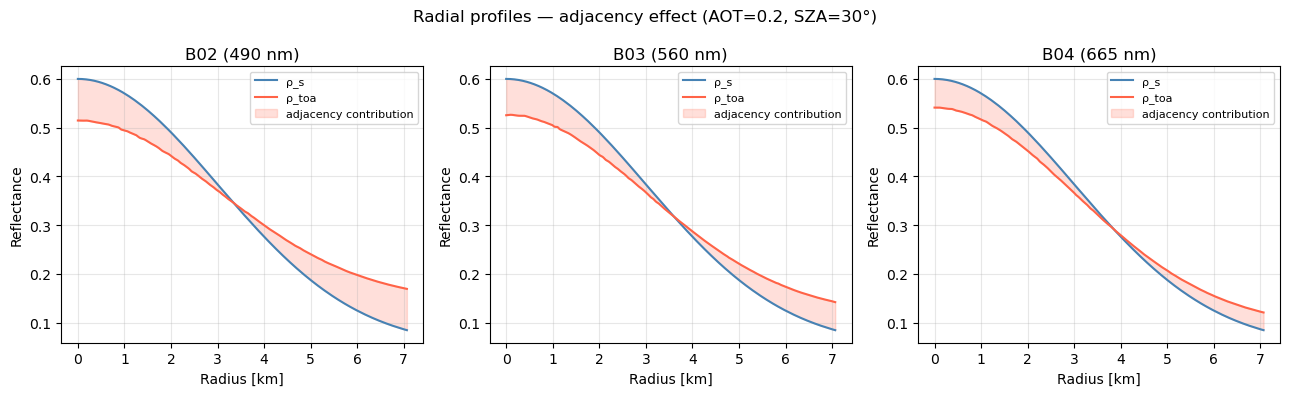

In [5]:
fig, axes = plt.subplots(1, len(BANDS), figsize=(13, 4))

for ax, band in zip(axes, BANDS):
    ds = scene[band]
    rho_s = ds["rho_s"]
    rho_toa = ds["rho_toa"].squeeze()

    profile_s = rho_s.adjeff.radial()
    profile_toa = rho_toa.adjeff.radial()

    ax.plot(profile_s.coords["r"], profile_s.values, label="ρ_s", color="steelblue")
    ax.plot(profile_toa.coords["r"], profile_toa.values, label="ρ_toa", color="tomato")
    ax.fill_between(
        profile_s.coords["r"],
        profile_s.values,
        profile_toa.values,
        alpha=0.2, color="tomato", label="adjacency contribution",
    )
    ax.set_title(f"{band.id} ({band.wl_nm:.0f} nm)")
    ax.set_xlabel("Radius [km]")
    ax.set_ylabel("Reflectance")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

fig.suptitle("Radial profiles — adjacency effect (AOT=0.2, SZA=30°)", fontsize=12)
plt.tight_layout()
plt.show()

## 4.5 — Effect of AOT on the adjacency contribution

Effects of the AOT on the TOA reflectance can be simply studied with the following configuration. See how the contrast gradually decrease with the AOT.

2026-04-15 11:53:12 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-15 11:53:12 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=1001 rho_max=0.6 rho_min=0.05 sigma=3.0 var=rho_s
2026-04-15 11:53:12 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=d0f0615b module=SmartgSampler_Rho_toa_sym
2026-04-15 11:53:12 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} other=['species', 'sat_height'] scalars=['sza', 'vza'] vectors=['aot', 'rh', 'h', 'href']
2026-04-15 11:53:12 [debug    ] Initialization finshed.        arrays={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']} deduplicated=False flat_dims=[]
2026-04-15 11:53:12 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=f5c23ce2 module=SmartgSampler_Rho_atm
2026-04-15 11:53:12 [debug    ] Aggregated Confi

/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/luts/luts.py:596: RuntimeWarning: invalid value encountered in divide
  return self.__binary_operation__(other, lambda x, y: x/y)
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:2352: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:2392: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]


Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:53:14 [info     ] rho_atm successfully calculated.
2026-04-15 11:53:14 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 1, 1, 1, 1, 1)
2026-04-15 11:53:14 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-15 11:53:14 [info     ] Computation finished           key=f5c23ce2 module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-15 11:53:14 [info     ] Start rho_toa computation.     band=S2Band.B02(490.0nm)
2026-04-15 11:53:14 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-15 11:53:14 [debug    ] Atmosphere LUT generation. wl=490.0, aot=0.0, rh=50.0, href=2.0, h=0.0
2026-04-15 11:53:14 [debug    ] Merge all atmospheres with multi-profile.


/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/luts/luts.py:596: RuntimeWarning: invalid value encountered in divide
  return self.__binary_operation__(other, lambda x, y: x/y)
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:2352: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]
/home/kwalcarius/dev/current/adjeff/.pixi/envs/notebooks-gpu/lib/python3.12/site-packages/smartg/smartg.py:2392: RuntimeWarning: invalid value encountered in divide
  scum /= scum[-1]


...

There is no current context to clear.
2026-04-15 11:53:37 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 1001, 1001)
2026-04-15 11:53:37 [info     ] Computed rho_toa.              band=S2Band.B02(490.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-15 11:53:37 [info     ] Computation finished           key=1c0955d3 module=SmartgSampler_Rho_toa_sym vars=['rho_toa']
2026-04-15 11:53:37 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-15 11:53:37 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=1001 rho_max=0.6 rho_min=0.05 sigma=3.0 var=rho_s
2026-04-15 11:53:37 [info     ] Starting compute               bands=[S2Band.B02(490.0nm)] key=7cdce85c module=SmartgSampler_Rho_toa_sym
2026-04-15 11:53:37 [debug    ] Aggregated ConfigBundle parameters.. das={'aot': ['aot'], 'h': ['h'], 'rh': ['rh'], 'href': ['href'], 'sza': ['sza'], 'vza': ['vza']

Box(children=(FloatProgress(value=0.0, max=30000000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:53:39 [info     ] rho_atm successfully calculated.
2026-04-15 11:53:39 [debug    ] Reconstructed original dimensions. dims=['vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h'] shape=(1, 1, 1, 1, 1, 1, 1)
2026-04-15 11:53:39 [info     ] Computed rho_atm.              dims=('vza', 'sza', 'wl', 'aot', 'rh', 'href', 'h')
2026-04-15 11:53:39 [info     ] Computation finished           key=a90881ac module=SmartgSampler_Rho_atm vars=['rho_atm']
2026-04-15 11:53:39 [info     ] Start rho_toa computation.     band=S2Band.B02(490.0nm)
2026-04-15 11:53:39 [debug    ] Sweep step                     coords={'sza': 30.0, 'vza': 0.0} step=1/1
2026-04-15 11:53:39 [debug    ] Atmosphere LUT generation. wl=490.0, aot=0.6, rh=50.0, href=2.0, h=0.0
2026-04-15 11:53:40 [debug    ] Merge all atmospheres with multi-profile.


Box(children=(FloatProgress(value=0.0, max=51500000.0), Label(value='')), layout=Layout(align_items='center', …

There is no current context to clear.
2026-04-15 11:53:49 [debug    ] Reconstructed original dimensions. dims=['aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x'] shape=(1, 1, 1, 1, 1, 1, 1001, 1001)
2026-04-15 11:53:49 [info     ] Computed rho_toa.              band=S2Band.B02(490.0nm) dims=('aot', 'rh', 'href', 'h', 'vza', 'sza', 'y', 'x')
2026-04-15 11:53:49 [info     ] Computation finished           key=7cdce85c module=SmartgSampler_Rho_toa_sym vars=['rho_toa']
2026-04-15 11:53:49 [debug    ] Creating Gaussian ImageDict.   bands=[S2Band.B02(490.0nm)]
2026-04-15 11:53:49 [debug    ] Created Gaussian Image.        band=S2Band.B02(490.0nm) n=1001 rho_max=0.6 rho_min=0.05 sigma=3.0 var=rho_s


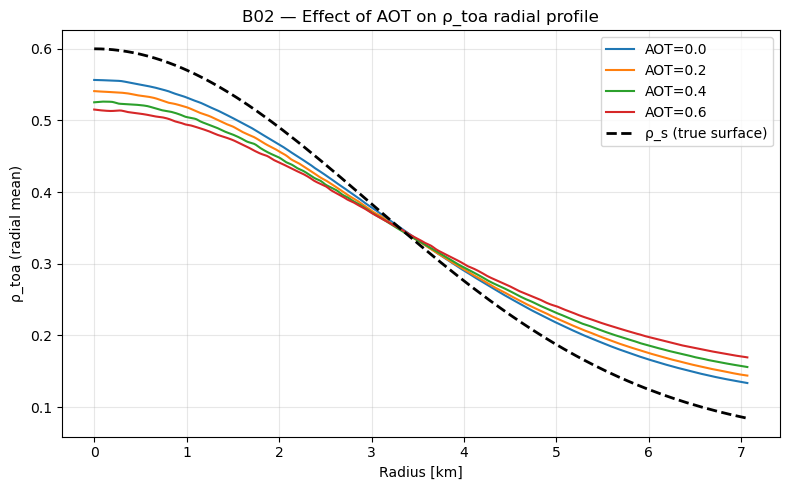

In [11]:
aot_test = [0.0, 0.20, 0.40, 0.60]
fig, ax = plt.subplots(figsize=(8, 5))

for aot_val in aot_test:
    atmo_test = AtmoConfig(
        aot=xr.DataArray([aot_val], dims=["aot"]),
        h=xr.DataArray([0.0], dims=["h"]),
        rh=xr.DataArray([50.0], dims=["rh"]),
        href=xr.DataArray([2.0], dims=["href"]),
        species={"sulphate": 1.0},
    )
    mod_test = SmartgSampler_Rho_toa_sym(
        atmo_config=atmo_test,
        geo_config=geo,
        remove_rayleigh=False,
        nr=80,
        n_ph=int(5e5),
    )
    scene_test = gaussian_image_dict(
        sigma=3.0, res_km=0.01, rho_min=0.05, rho_max=0.6,
        bands=[S2Band.B02], n=1001,
    )
    scene_test = mod_test(scene_test)
    rho_toa = scene_test[S2Band.B02]["rho_toa"].squeeze()
    profile = rho_toa.adjeff.radial()
    ax.plot(profile.coords["r"], profile.values, label=f"AOT={aot_val}")

# Reference surface profile
rho_s_ref = gaussian_image_dict(
    sigma=3.0, res_km=0.01, rho_min=0.05, rho_max=0.6,
    bands=[S2Band.B02], n=1001,
)[S2Band.B02]["rho_s"]
profile_s = rho_s_ref.adjeff.radial()
ax.plot(
    profile_s.coords["r"], 
    profile_s.values, 
    "k--", 
    label="ρ_s (true surface)", 
    linewidth=2,
)

ax.set_xlabel("Radius [km]")
ax.set_ylabel("ρ_toa (radial mean)")
ax.set_title("B02 — Effect of AOT on ρ_toa radial profile")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()